In [13]:
import pandas as pd
df1 = pd.read_csv('cars.csv')

In [15]:
df1

,Id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,city,brand_rank,car_age
0,0,2016,Honda,Honda Brio S MT,Brio,425000.0,9680.0,Petrol,Mumbai,7,5.0
1,1,2012,Nissan,Nissan Sunny XV Diesel,Sunny,325000.0,119120.0,Diesel,Mumbai,11,9.0
2,2,2017,Toyota,Toyota Fortuner 2.8 4x2 MT [2016-2020],Fortuner,2650000.0,64593.0,Diesel,Thane,1,4.0
3,3,2017,Mercedes-Benz,Mercedes-Benz E-Class E 220d Expression [2019-...,E-Class,4195000.0,25000.0,Diesel,Mumbai,2,4.0
4,4,2012,Hyundai,Hyundai Verna Fluidic 1.6 CRDi SX,Verna,475000.0,23800.0,Diesel,Mumbai,14,9.0
...,...,...,...,...,...,...,...,...,...,...,...
1720,1720,2015,Hyundai,Hyundai Eon Era +,Eon,290000.0,38000.0,Petrol,Pune,14,6.0
1721,1721,2011,Bentley,Bentley Continental Flying Spur W12,Continental,7500000.0,36000.0,Petrol,Pune,44,10.0
1722,1722,2008,Mahindra-Renault,Mahindra-Renault Logan DLE 1.5 dci,Logan,185000.0,142522.0,Diesel,Pune,24,13.0
1723,1723,1990,Mahindra,Mahindra Jeep CJ 500 D,Jeep,325000.0,18581.0,Diesel,Pune,24,31.0


In [17]:
from sklearn import preprocessing

le=preprocessing.LabelEncoder()

df2=df1

df2.brand = le.fit_transform(df2.brand)
df2.full_model_name = le.fit_transform(df2.full_model_name)

df2.model_name = le.fit_transform(df2.model_name)

df2.fuel_type = le.fit_transform(df2.fuel_type)

df2.city = le.fit_transform(df2.city)

df2.brand = le.fit_transform(df2.brand)

df2

,Id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,city,brand_rank,car_age
0,0,2016,7,131,28,425000.0,9680.0,3,9,7,5.0
1,1,2012,23,570,129,325000.0,119120.0,1,9,11,9.0
2,2,2017,28,676,69,2650000.0,64593.0,1,14,1,4.0
3,3,2017,21,526,51,4195000.0,25000.0,1,9,2,4.0
4,4,2012,8,259,144,475000.0,23800.0,1,9,14,9.0
...,...,...,...,...,...,...,...,...,...,...,...
1720,1720,2015,8,221,59,290000.0,38000.0,3,13,14,6.0
1721,1721,2011,2,80,41,7500000.0,36000.0,3,13,44,10.0
1722,1722,2008,19,391,96,185000.0,142522.0,1,13,24,13.0
1723,1723,1990,18,347,89,325000.0,18581.0,1,13,24,31.0


In [65]:
print(df2.var())
print(df2.var().min())

df3=df2.drop('city',axis="columns")
df3
df3.drop("distance_travelled(kms)",axis="columns",inplace=True)
df3.drop("model_name",axis="columns",inplace=True)

Id                         2.481125e+05
year                       1.028808e+01
brand                      8.461353e+01
full_model_name            4.718125e+04
model_name                 2.392481e+03
price                      2.794440e+12
distance_travelled(kms)    2.000374e+09
fuel_type                  1.017958e+00
city                       1.874791e+01
brand_rank                 1.677315e+02
car_age                    1.028808e+01
dtype: float64
1.0179582366589184


In [67]:
X=df3.drop('price',axis="columns")
Y=df3[['price']]
print(type(Y))
print(type(X))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

In [71]:
#standardization of dataset
from sklearn.preprocessing import StandardScaler

#standardise the Training Dataset
X_train_std = pd.DataFrame(StandardScaler().fit_transform(X_train))
#X_train_std.columns = X_train.columns
# X_train_std.head()

#standardise the Testing Dataset
X_test_std = pd.DataFrame(StandardScaler().fit_transform(X_test))
# X_test_std.columns = X_test.columns
# X_test_std.head()

In [73]:
from sklearn import linear_model

model=linear_model.LinearRegression()
model.fit(X_train_std,Y_train)

LinearRegression()

In [75]:
Y_pred=model.predict(X_test_std)
print(type(Y_pred))
print((type(Y_test)))
y_pred_df=pd.DataFrame({'res':Y_pred[:,0]})

from sklearn.metrics import mean_absolute_percentage_error

print(mean_absolute_percentage_error(Y_test,y_pred_df))

<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>
0.8795540490031575


In [77]:
from sklearn.metrics import mean_squared_error, r2_score
print(r2_score(Y_test,y_pred_df))

0.23354632556925625


In [49]:
# to find the train score
dt_train_score = model.score(X_train_std,Y_train)
# to find the test score
dt_test_score = model.score(X_test_std,Y_test)
 

In [82]:

from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=500,max_features='log2', max_depth=50,random_state=42,max_samples=0.99)
rf_regressor.fit(X_train, Y_train)

y_pred = rf_regressor.predict(X_test)
mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print('..........',mse)
print(r2)

/home/admin1/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


.......... 972722625803.7826
0.7102417042365274


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

In [59]:

from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=500,max_features='log2', max_depth=50,random_state=42,max_samples=0.99)
rf_regressor.fit(X_train, y_train)

y_pred = rf_regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('..........',mse)
print(r2)

/home/admin1/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


.......... 1023532758487.1362
0.6951061896887099


/home/admin1/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


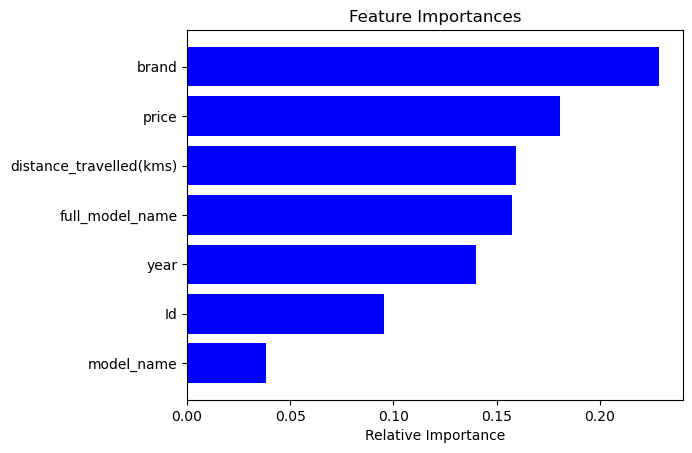

In [61]:
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=500,max_features='log2', max_depth=50,random_state=42,max_samples=0.99)
rf_regressor.fit(X_train, y_train)

y_pred = rf_regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
features = df2.columns
importances = rf_regressor.feature_importances_
indices = np.argsort(importances)[-9:]  # top 10 features
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [62]:
#df2.drop("Id",axis="columns",inplace=True)
#df3.drop("city",axis="columns",inplace=True)

#df3.drop("distance_travelled(kms)",axis="columns",inplace=True)
#df3.drop("year",axis="columns",inplace=True)
X=df3.drop('price',axis="columns")
Y=df3[['price']]
print(type(Y))
print(type(X))
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=500,max_features='log2', max_depth=50,random_state=42,max_samples=0.99)
rf_regressor.fit(X_train, y_train)

y_pred = rf_regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("mse",mse)
print(mean_absolute_percentage_error(y_test,y_pred_df))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


/home/admin1/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


mse 1023532758487.1362
0.8455291801127667
